# Performance

Two things make this library fast, and they are worth knowing in order of importance: **pass arrays instead of looping**, which costs nothing and wins the most, and **install the optional compiled backend** if the scans are large.

Every number below is measured when the notebook runs, so it reflects the machine that produced this copy rather than a figure carried over from a README.

In [1]:
import sys
import os

# Works whether or not the package is installed: these notebooks sit one
# level below the repository root, so src/ is one directory up.
sys.path.insert(0, os.path.abspath(os.path.join('..', 'src')))

import numpy as np
import matplotlib.pyplot as plt

import globaldefs as gd
import oscprob2nu
import oscprob3nu
import oscprob4nu
import hamiltonians2nu
import hamiltonians3nu
import hamiltonians4nu

%matplotlib inline
plt.rcParams.update({'figure.figsize': (7.2, 4.2), 'figure.dpi': 90,
                     'axes.grid': True, 'grid.alpha': 0.3,
                     'font.size': 11, 'legend.frameon': False,
                     # Axes end exactly at the data: no padding beyond
                     # x_min/x_max or y_min/y_max.
                     'axes.xmargin': 0.0, 'axes.ymargin': 0.0})

# The three-flavor vacuum Hamiltonian at the NuFit best fit, normal ordering.
# It is energy-independent; dividing by the energy is what the builders do.
H_VAC_3NU = hamiltonians3nu.hamiltonian_3nu_vacuum_energy_independent(
    gd.S12_NO_BF, gd.S23_NO_BF, gd.S13_NO_BF, gd.DCP_NO_BF,
    gd.D21_NO_BF, gd.D31_NO_BF)

KM = gd.CONV_KM_TO_INV_EV      # multiply a length in km to get eV^-1
GEV = 1.0e9                    # multiply an energy in GeV to get eV

In [2]:
import time

import fastkernels


def best_of(func, repeat=5):
    """Returns the fastest of `repeat` runs, in seconds.

    The minimum, not the mean: timing noise is one-sided, so
    the fastest run is the one least polluted by whatever else
    the machine was doing.
    """
    best = float("inf")
    for _ in range(repeat):
        t0 = time.perf_counter()
        func()
        best = min(best, time.perf_counter()-t0)
    return best


print("Numba available:", fastkernels.HAVE_NUMBA)

Numba available: True


## Looping versus broadcasting

The same energy scan, done both ways. The batched call is one invocation; the loop is one per point.

In [3]:
n_points = 2000
E_gev = np.logspace(-1.0, 1.5, n_points)
L = 1300.0*KM

H_stack = hamiltonians3nu.hamiltonian_3nu_matter(
    H_VAC_3NU, E_gev*GEV, gd.VCC_EARTH_CRUST)


def batched():
    return oscprob3nu.probabilities_3nu(H_stack, L)


def looped():
    return [oscprob3nu.probabilities_3nu(h, L) for h in H_stack]


t_batch = best_of(batched)
t_loop = best_of(looped, repeat=3)

print("loop over %d points : %8.2f ms" % (n_points, t_loop*1e3))
print("one batched call   : %8.2f ms" % (t_batch*1e3))
print("speedup            : %8.1fx" % (t_loop/t_batch))

loop over 2000 points :    31.98 ms
one batched call   :     0.29 ms
speedup            :    109.7x


The two agree exactly — this is the same arithmetic, organised differently:

In [4]:
print("max |batched - looped| = %.2e"
      % np.max(np.abs(np.array(batched()) - np.array(looped()))))

max |batched - looped| = 7.83e-14


## How the gain scales

The advantage grows with the size of the scan, because the fixed cost of a batched call is amortised over more points. Below a handful of elements the library detects this and takes the scalar path instead — that is what `oscprob3nu.SMALL_BATCH` is for.

In [5]:
sizes = [1, 3, 10, 30, 100, 300, 1000, 3000, 10000]
rows = []
for n in sizes:
    E = np.logspace(-1.0, 1.5, n)
    Hs = hamiltonians3nu.hamiltonian_3nu_matter(
        H_VAC_3NU, E*GEV, gd.VCC_EARTH_CRUST)
    tb = best_of(lambda: oscprob3nu.probabilities_3nu(Hs, L))
    tl = best_of(lambda: [oscprob3nu.probabilities_3nu(h, L)
                          for h in Hs], repeat=3)
    rows.append((n, tl, tb))

rows = np.array(rows)
print("%8s %12s %12s %9s" % ("N", "loop [ms]", "batched [ms]",
                            "speedup"))
for n, tl, tb in rows:
    print("%8d %12.3f %12.3f %8.1fx" % (n, tl*1e3, tb*1e3, tl/tb))

       N    loop [ms] batched [ms]   speedup
       1        0.022        0.027      0.8x
       3        0.054        0.023      2.3x
      10        0.162        0.024      6.9x
      30        0.493        0.029     17.0x
     100        1.610        0.045     36.0x
     300        4.762        0.106     44.9x
    1000       15.821        0.176     89.8x
    3000       47.984        0.303    158.5x
   10000      159.294        0.610    261.3x


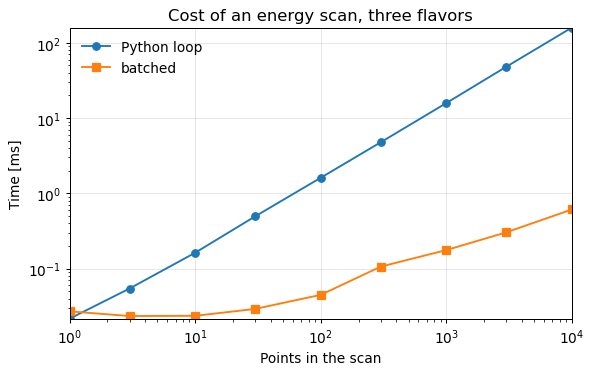

In [6]:
fig, ax = plt.subplots()
ax.loglog(rows[:, 0], rows[:, 1]*1e3, "o-", label="Python loop")
ax.loglog(rows[:, 0], rows[:, 2]*1e3, "s-", label="batched")
ax.set_xlim(rows[0, 0], rows[-1, 0])
ax.set_xlabel("Points in the scan")
ax.set_ylabel("Time [ms]")
ax.set_title("Cost of an energy scan, three flavors")
ax.legend()
plt.show()

## The compiled backend

With `numba` installed, the batched paths hand large stacks to a compiled kernel. It is switchable at runtime, which is how the regression suite checks the two paths against each other — and is what makes the comparison below possible in one process.

In [7]:
if not fastkernels.HAVE_NUMBA:
    print("numba is not installed; skipping this comparison.")
else:
    n = 200000
    E = np.logspace(-1.0, 1.5, n)
    Hs = hamiltonians3nu.hamiltonian_3nu_matter(
        H_VAC_3NU, E*GEV, gd.VCC_EARTH_CRUST)

    # Warm the cache: the first call compiles.
    oscprob3nu.probabilities_3nu(Hs[:100], L)

    fastkernels.USE_NUMBA = True
    t_kernel = best_of(lambda: oscprob3nu.probabilities_3nu(Hs, L))
    fastkernels.USE_NUMBA = False
    t_numpy = best_of(lambda: oscprob3nu.probabilities_3nu(Hs, L))
    fastkernels.USE_NUMBA = True

    print("%d energies, three flavors" % n)
    print("  NumPy path     : %8.1f ms" % (t_numpy*1e3))
    print("  compiled kernel: %8.1f ms" % (t_kernel*1e3))
    print("  speedup        : %8.1fx" % (t_numpy/t_kernel))

200000 energies, three flavors
  NumPy path     :    204.6 ms
  compiled kernel:     19.6 ms
  speedup        :     10.4x


The two paths agree to round-off, which is the property that makes the backend safe to install and forget about:

In [8]:
if fastkernels.HAVE_NUMBA:
    Hs = hamiltonians3nu.hamiltonian_3nu_matter(
        H_VAC_3NU, np.logspace(-1, 1.5, 5000)*GEV,
        gd.VCC_EARTH_CRUST)
    fastkernels.USE_NUMBA = True
    a = np.array(oscprob3nu.probabilities_3nu(Hs, L))
    fastkernels.USE_NUMBA = False
    b = np.array(oscprob3nu.probabilities_3nu(Hs, L))
    fastkernels.USE_NUMBA = True
    print("max |kernel - numpy| = %.2e" % np.max(np.abs(a-b)))

max |kernel - numpy| = 3.44e-15


## Where the backend does *not* help

The two-flavor expansion reduces to a square root and a sine per element, which NumPy already does about as well as compiled code can. The library therefore declines the kernel below a measured threshold rather than using it everywhere — a backend that is sometimes slower than the path it replaces is worse than no backend.

In [9]:
print("thresholds at which the compiled kernel is used:")
for n_flavors, threshold in sorted(fastkernels.MIN_BATCH.items()):
    print("  %d flavors: stacks of %d or more"
          % (n_flavors, threshold))
print()
print("below these sizes the NumPy path is used, whether or "
      "not numba is installed")

thresholds at which the compiled kernel is used:
  2 flavors: stacks of 50000 or more
  3 flavors: stacks of 1 or more

below these sizes the NumPy path is used, whether or not numba is installed


## What to take away

1. Replace loops with array arguments. This is the large win, it needs no extra dependency, and the results are identical.
2. If the scans are large and three-flavor, `pip install "nuoscprobexact[fast]"` on top of that.
3. Do not bother for a handful of points: the library already takes the quicker path there on its own.